In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow import keras
from tensorflow.keras.regularizers import l2

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

## Reading Dataset

In [3]:
df = pd.read_csv("Home_loan_data.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [6]:
df.dtypes

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE                  str
CODE_GENDER                         str
FLAG_OWN_CAR                        str
FLAG_OWN_REALTY                     str
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                     str
NAME_INCOME_TYPE                    str
NAME_EDUCATION_TYPE                 str
NAME_FAMILY_STATUS                  str
NAME_HOUSING_TYPE                   str
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64


In [7]:
df.shape

(307511, 122)

## Data Preporcessing

In [8]:
null = pd.DataFrame(df.isnull().sum()/df.shape[0]).reset_index()
null.columns=['Features','Null']
null_gt_45= null[null['Null']>0.45].sort_values(by=['Null'], ascending=False)['Features'].to_list()
len(null_gt_45)

49

In [39]:
null[null['Null']>0].shape

(67, 2)

In [9]:
df1 = df.drop(null_gt_45, axis=1)
df1 = df1.fillna(0)
df1.shape

(307511, 73)

In [10]:
df1 = df1.drop(['SK_ID_CURR'], axis=1)

In [11]:
low_variance_cols = []

for col in df1.columns:
    if df1[col].value_counts(normalize=True).iloc[0] > 0.95:
        low_variance_cols.append(col)

print(low_variance_cols)

df1 = df1.drop(columns=low_variance_cols)
df1.shape

['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'REG_REGION_NOT_LIVE_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK']


(307511, 48)

In [ ]:
### Inferences:
### 67 features have null values, with majority of them having more than 50% null.
### We are dropping features with >45% null and for rest, imputing 0 in place of null.
### Dropping unique identifier column as it is not going to add any value to our model
### Dropping features where one category has >95% frequency, indicating massive skewness


In [13]:
### Checking correlation among variables

### Sorting variable pairs in descending order of absolute correlation

corr_matrix = df1.corr(numeric_only=True, method='spearman')

corr_pairs = (
    corr_matrix
    .abs()                          
    .unstack()                      
    .reset_index()
)

corr_pairs.columns = ['var1', 'var2', 'correlation']

# remove self correlations
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]

# remove duplicate pairs (A,B) and (B,A)
corr_pairs['pair_key'] = corr_pairs.apply(
    lambda x: tuple(sorted([x['var1'], x['var2']])), axis=1
)
corr_pairs = corr_pairs.drop_duplicates(subset='pair_key')


corr_pairs = corr_pairs.sort_values(by='correlation', ascending=False)

corr_pairs.head(10)

,var1,var2,correlation,pair_key
927,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.997338,"(OBS_30_CNT_SOCIAL_CIRCLE, OBS_60_CNT_SOCIAL_CIRCLE)"
113,AMT_CREDIT,AMT_GOODS_PRICE,0.984487,"(AMT_CREDIT, AMT_GOODS_PRICE)"
593,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.950041,"(REGION_RATING_CLIENT, REGION_RATING_CLIENT_W_CITY)"
964,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.845159,"(DEF_30_CNT_SOCIAL_CIRCLE, DEF_60_CNT_SOCIAL_CIRCLE)"
112,AMT_CREDIT,AMT_ANNUITY,0.830167,"(AMT_ANNUITY, AMT_CREDIT)"
149,AMT_ANNUITY,AMT_GOODS_PRICE,0.827963,"(AMT_ANNUITY, AMT_GOODS_PRICE)"
778,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,0.825575,"(LIVE_CITY_NOT_WORK_CITY, REG_CITY_NOT_WORK_CITY)"
51,CNT_CHILDREN,CNT_FAM_MEMBERS,0.811556,"(CNT_CHILDREN, CNT_FAM_MEMBERS)"
299,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.667354,"(DAYS_EMPLOYED, FLAG_EMP_PHONE)"
263,DAYS_BIRTH,FLAG_EMP_PHONE,0.599551,"(DAYS_BIRTH, FLAG_EMP_PHONE)"


In [14]:
### Dropping one feature from pairs with 90+ correlation
df1 = df1.drop(['OBS_30_CNT_SOCIAL_CIRCLE','AMT_CREDIT','REGION_RATING_CLIENT'], axis=1) 

In [15]:
multi_val_cols = [col for col in df1.columns if df1[col].nunique() <= 3]

print(multi_val_cols)
print(len(multi_val_cols))

['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT_W_CITY', 'REG_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_8']
17


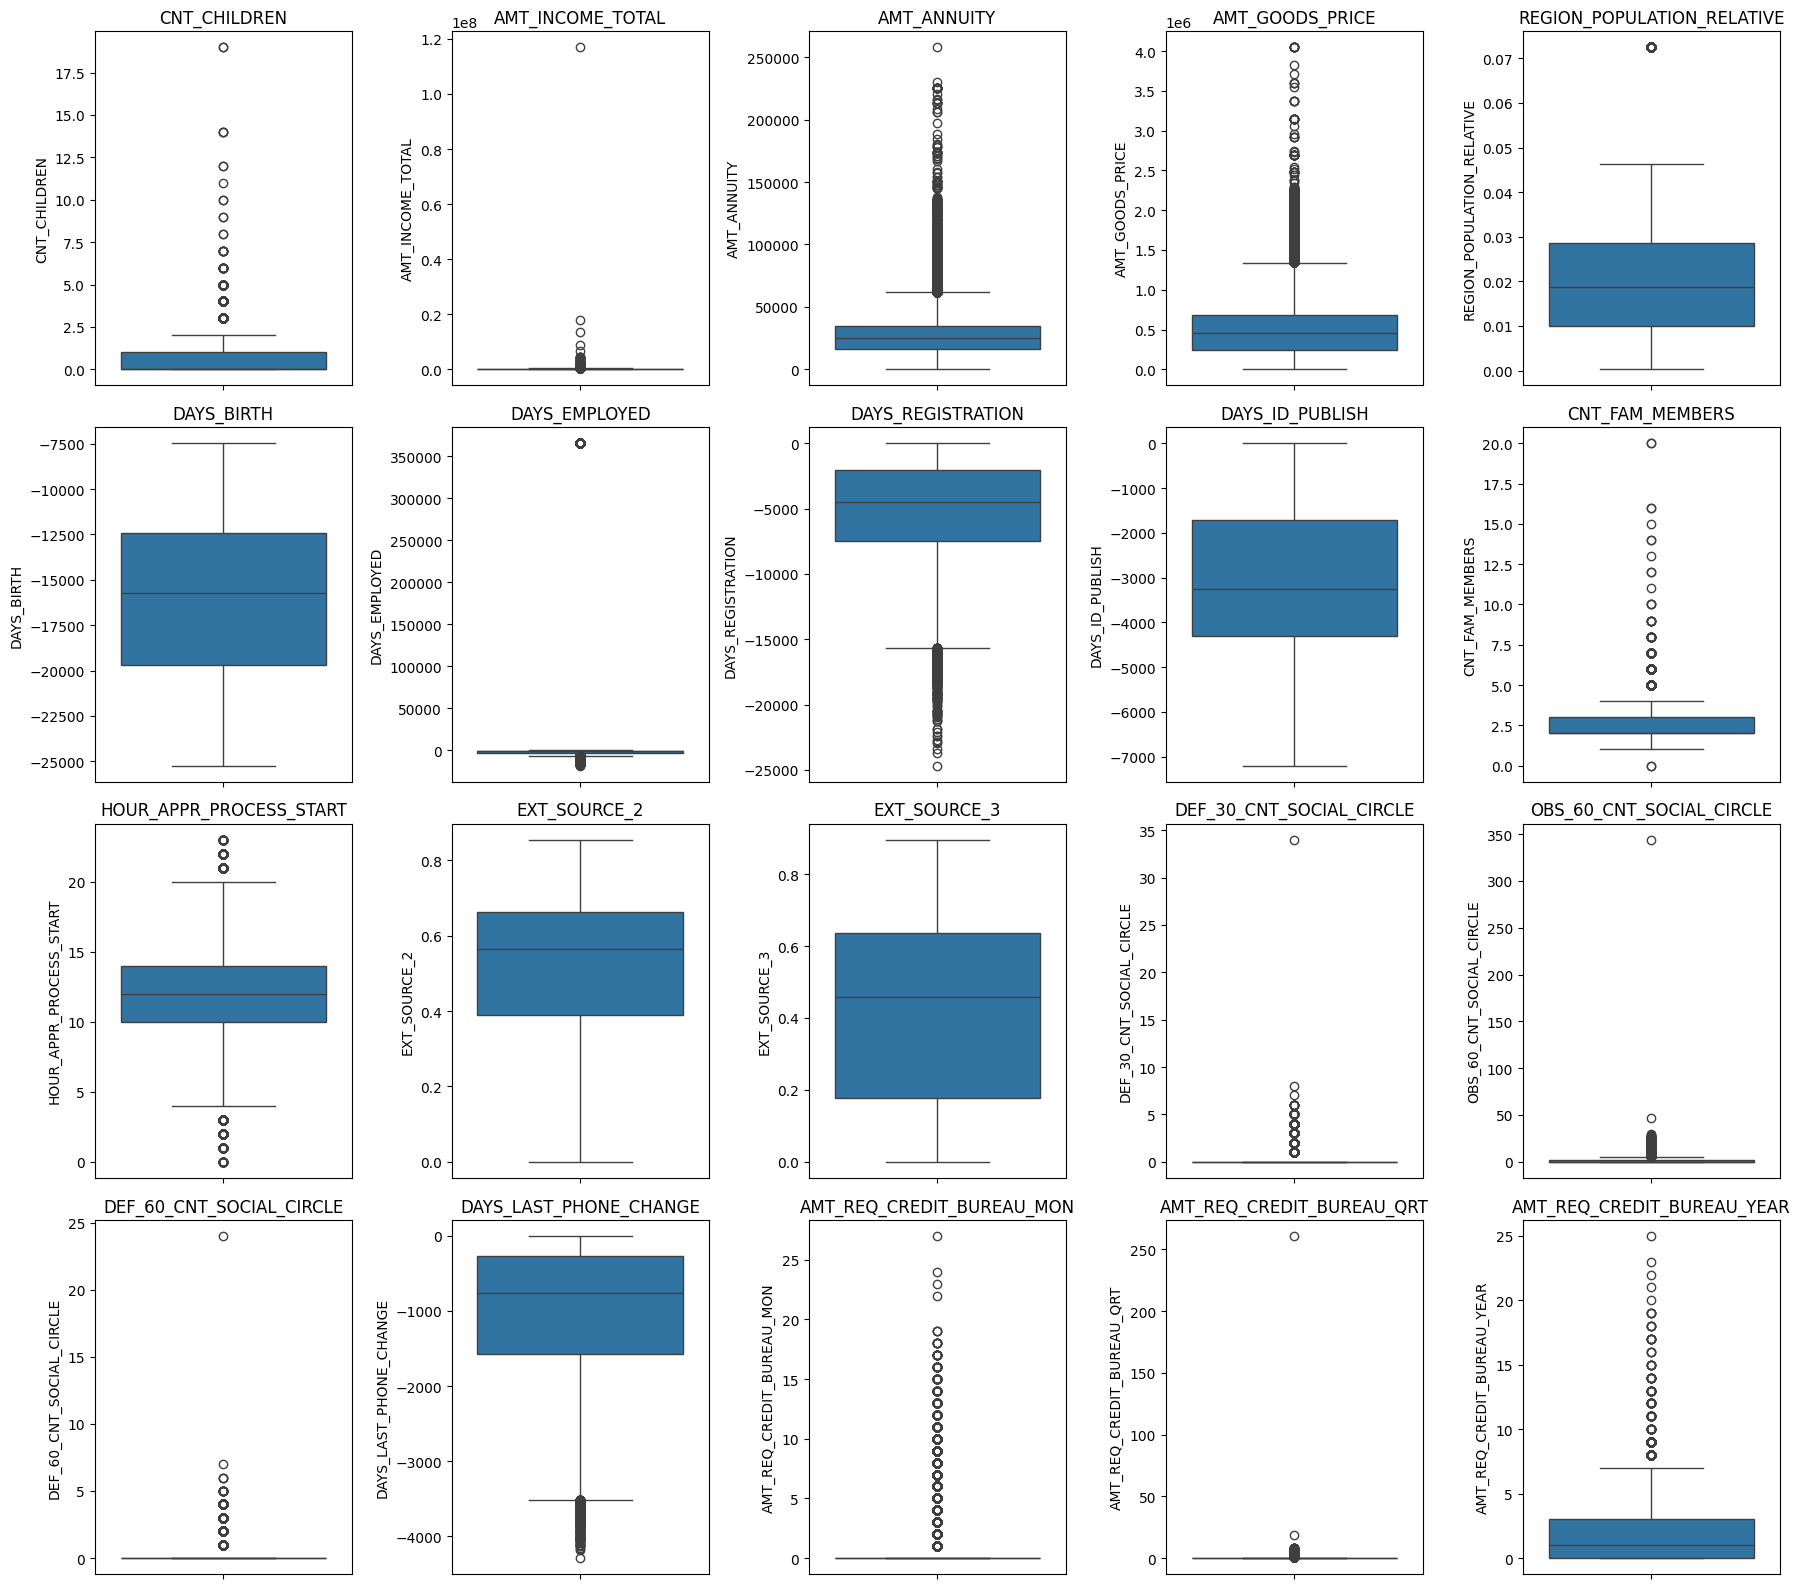

In [16]:
### Box plot of all continuous features

num_cols = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col not in multi_val_cols]


n_cols = 5
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df1[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [17]:
### Inferences:
### Strong right-skew in AMT_INCOME_TOTAL, AMT_ANNUITY, AMT_GOODS_PRICE, TOTALAREA_MODE
### Moderate left-skew in DAYS_LAST_PHONE_CHANGE, DAYS_REGISTRATION.
### Some of the CNT features have few extreme values.
### Bureau Inquiry feature sare mostly zero and have a few outliers.

C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_22928\1278577958.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()


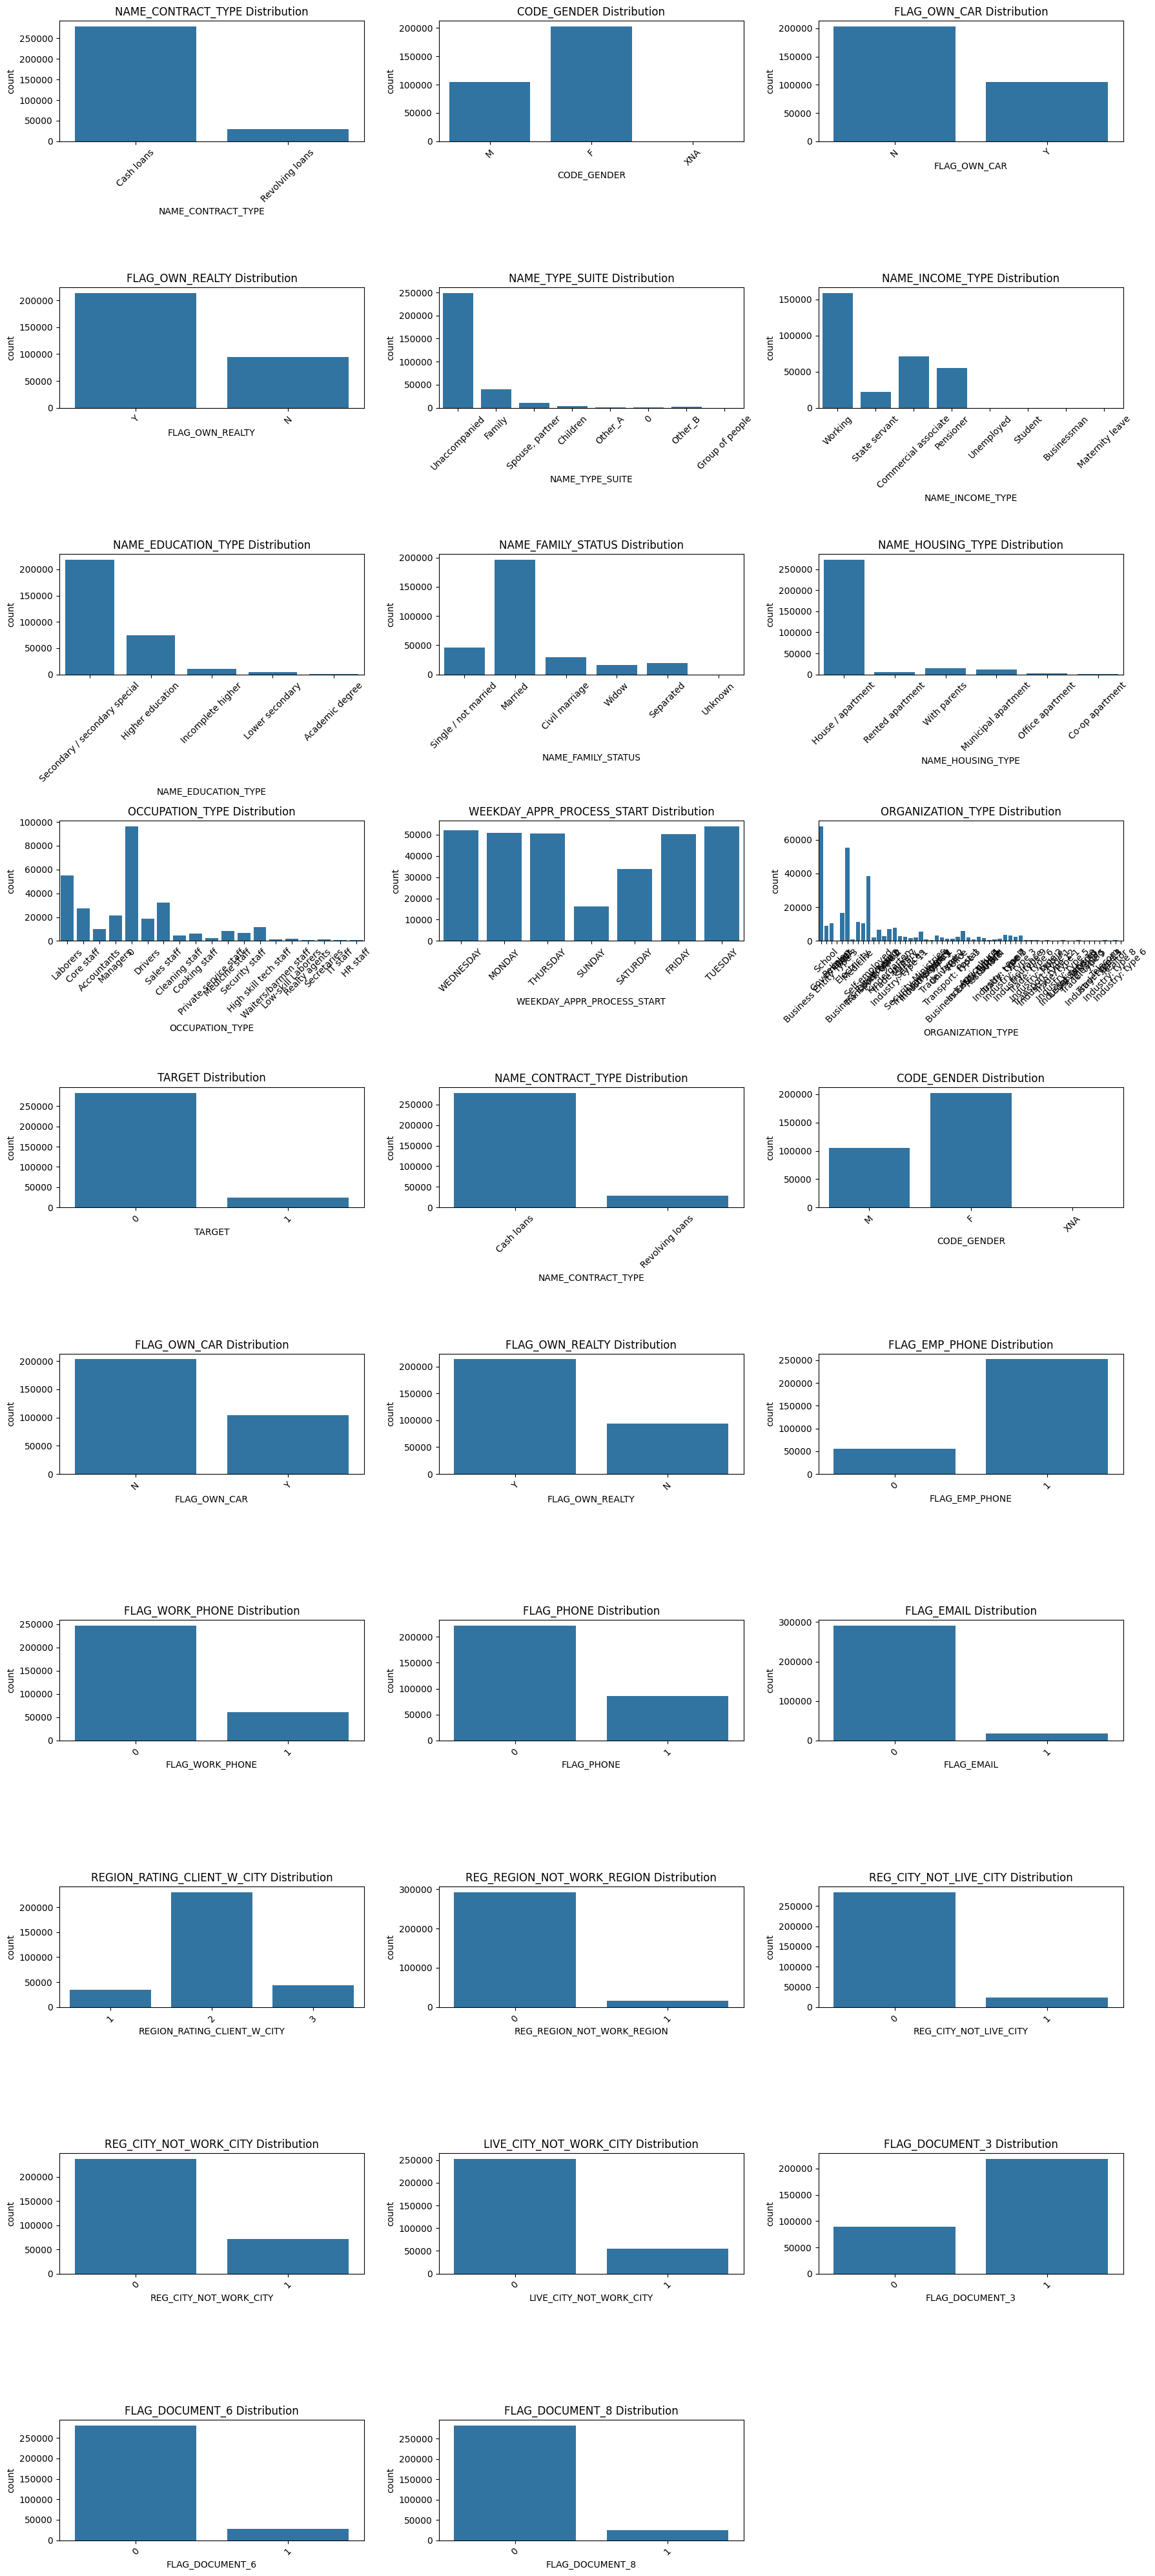

In [18]:
## count plots for categrorical / discrete variables

cat_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()

cat_cols += multi_val_cols

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=df1[col], ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=45)

# remove extra plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
df1['TARGET'].value_counts()/df1.shape[0]

TARGET
0    0.919271
1    0.080729
Name: count, dtype: float64

In [20]:
### Most of the categorical variables have highly imbalanced distribution.
### The Target flag is highly imbalanced, with the event rate being around 8%.


## Encoding categorical variables

In [21]:
### Binary columns encoding(mapping 0/1)

binary_cols = [
 'FLAG_OWN_CAR','FLAG_OWN_REALTY','CODE_GENDER',
 'FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL'
]

df1['FLAG_OWN_CAR'] = df1['FLAG_OWN_CAR'].map({'Y':1,'N':0})
df1['FLAG_OWN_REALTY'] = df1['FLAG_OWN_REALTY'].map({'Y':1,'N':0})
df1['CODE_GENDER'] = df1['CODE_GENDER'].map({'M':2,'F':1, 'XNA':4})

In [22]:
cat_cols=df1.select_dtypes(include=['object', 'category']).columns.tolist()
df1[cat_cols].dtypes

C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_22928\429010476.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df1.select_dtypes(include=['object', 'category']).columns.tolist()


NAME_CONTRACT_TYPE               str
NAME_TYPE_SUITE               object
NAME_INCOME_TYPE                 str
NAME_EDUCATION_TYPE              str
NAME_FAMILY_STATUS               str
NAME_HOUSING_TYPE                str
OCCUPATION_TYPE               object
WEEKDAY_APPR_PROCESS_START       str
ORGANIZATION_TYPE                str
dtype: object

In [23]:
### ordinal encoding for all other categorical features

from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df1[cat_cols] = df1[cat_cols].astype(str)
df1[cat_cols] = enc.fit_transform(df1[cat_cols])

In [24]:
df1.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,0.0,2,0,1,0,202500.0,24700.5,351000.0,7.0,7.0,4.0,3.0,1.0,0.018801,-9461,-637,-3648.0,-2120,1,0,1,0,9.0,1.0,2,6.0,10,0,0,0,0,5.0,0.262949,0.139376,2.0,2.0,2.0,-1134.0,1,0,0,0.0,0.0,1.0
1,0,0.0,1,0,0,0,270000.0,35698.5,1129500.0,2.0,4.0,1.0,1.0,1.0,0.003541,-16765,-1188,-1186.0,-291,1,0,1,0,4.0,2.0,1,1.0,11,0,0,0,0,39.0,0.622246,0.000000,0.0,1.0,0.0,-828.0,1,0,0,0.0,0.0,0.0
2,0,1.0,2,1,1,0,67500.0,6750.0,135000.0,7.0,7.0,4.0,3.0,1.0,0.010032,-19046,-225,-4260.0,-2531,1,1,1,0,9.0,1.0,2,1.0,9,0,0,0,0,11.0,0.555912,0.729567,0.0,0.0,0.0,-815.0,0,0,0,0.0,0.0,0.0
3,0,0.0,1,0,1,0,135000.0,29686.5,297000.0,7.0,7.0,4.0,0.0,1.0,0.008019,-19005,-3039,-9833.0,-2437,1,0,0,0,9.0,2.0,2,6.0,17,0,0,0,0,5.0,0.650442,0.000000,0.0,2.0,0.0,-617.0,1,0,0,0.0,0.0,0.0
4,0,0.0,2,0,1,0,121500.0,21865.5,513000.0,7.0,7.0,4.0,3.0,1.0,0.028663,-19932,-3038,-4311.0,-3458,1,0,0,0,4.0,1.0,2,4.0,11,0,0,1,1,37.0,0.322738,0.000000,0.0,0.0,0.0,-1106.0,0,0,1,0.0,0.0,0.0


## Train-Test Split and SMOTE

In [25]:
from sklearn.model_selection import train_test_split

X = df1.drop(columns=['TARGET'])
y = df1['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

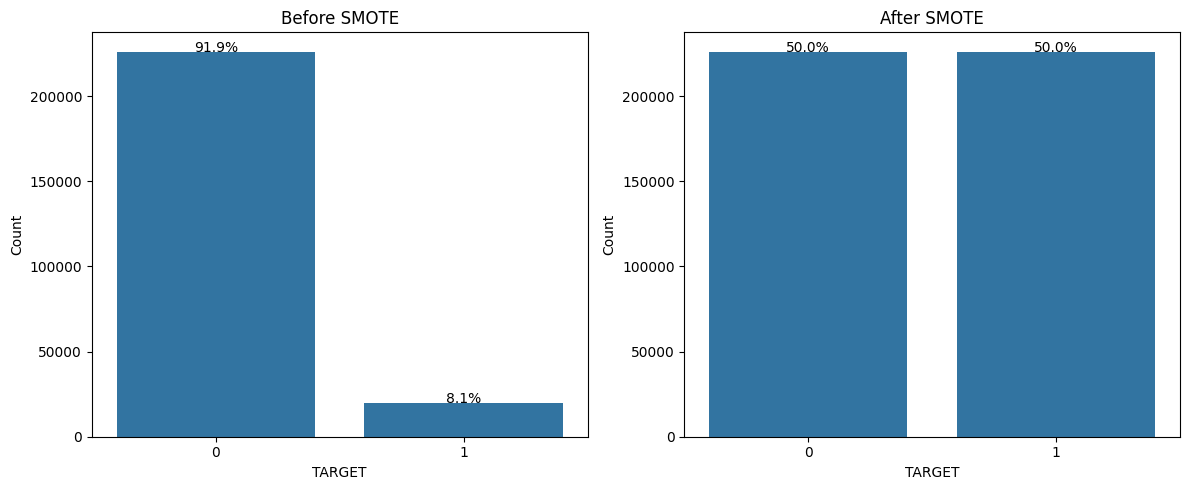

In [28]:
### Target distribution before and after SMOTE in tarining datset
# ---- No need of SMOTE in test -----#
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert to Series (in case y_train_sm is numpy)
y_train_sm_series = pd.Series(y_train_sm, name='TARGET')

# Get counts
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_sm_series.value_counts().sort_index()

# Create DataFrame
plot_df = pd.DataFrame({
    'Before SMOTE': before_counts,
    'After SMOTE': after_counts
}).fillna(0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
sns.barplot(x=plot_df.index, y=plot_df['Before SMOTE'], ax=axes[0])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('TARGET')
axes[0].set_ylabel('Count')

# After SMOTE
sns.barplot(x=plot_df.index, y=plot_df['After SMOTE'], ax=axes[1])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('TARGET')
axes[1].set_ylabel('Count')

for ax, col in zip(axes, ['Before SMOTE', 'After SMOTE']):
    total = plot_df[col].sum()
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2,
                height,
                f'{height/total:.1%}',
                ha='center')
        
plt.tight_layout()
plt.show()

In [ ]:
### Applying SMOTE has made the minority class 50% from 8.1%.

## ANN Model

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_sm.shape[1]),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.2,
    epochs=60,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\Saptarshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8194 - loss: 0.4130 - val_accuracy: 0.8673 - val_loss: 0.2659
Epoch 2/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8519 - loss: 0.3554 - val_accuracy: 0.8726 - val_loss: 0.2489
Epoch 3/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8604 - loss: 0.3379 - val_accuracy: 0.8643 - val_loss: 0.2643
Epoch 4/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8640 - loss: 0.3294 - val_accuracy: 0.8762 - val_loss: 0.2399
Epoch 5/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8687 - loss: 0.3215 - val_accuracy: 0.8898 - val_loss: 0.2190
Epoch 6/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8717 - loss: 0.3155 - val_accuracy: 0.8845 - val_loss: 0.2273
Epoch 7/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8736 - loss: 0.3111 - val_accuracy: 0.9011 - val_loss: 0.1981
Epoch 8/60
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8747 - loss: 0.3083 - val_accuracy: 0.

In [ ]:
### Sigmoid activation function used in final layer as only one output neuron(0/1)
### Have used batch normalization to enable faster training and dropout to prevent overfitting
### Have taken 4 dense layers

In [31]:
model.evaluate(X_test, y_test)

1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9010 - loss: 0.2872


[0.28723883628845215, 0.9009966850280762]

In [32]:
model.evaluate(X_train_sm, y_train_sm)

14135/14135 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.9121 - loss: 0.2226


[0.22255046665668488, 0.9120752811431885]

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,925 (195.02 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 33,028 (129.02 KB)

In [34]:
y_prob = model.predict(X_test)
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC on test:", roc_auc)

y_prob_train = model.predict(X_train_sm)
roc_auc = roc_auc_score(y_train_sm, y_prob_train)
print("ROC-AUC on train:", roc_auc)


1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 883us/step
ROC-AUC on test: 0.7146491249350712
14135/14135 ━━━━━━━━━━━━━━━━━━━━ 12s 820us/step
ROC-AUC on train: 0.9631758202272479


1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step
14135/14135 ━━━━━━━━━━━━━━━━━━━━ 11s 812us/step
ROC-AUC on Test: 0.7146491249350712
ROC-AUC on Train: 0.9631758202272479


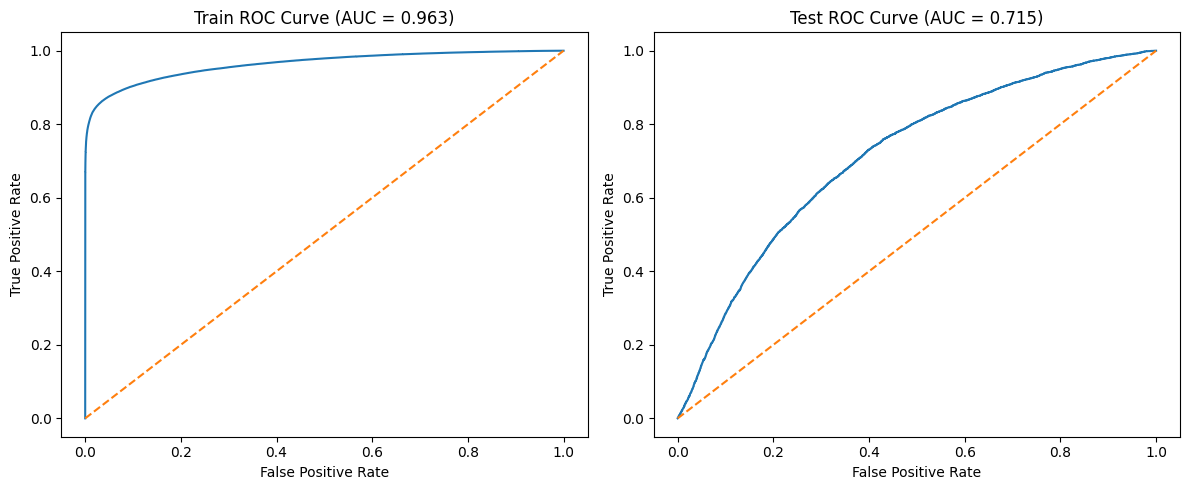

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predictions
y_prob_test = model.predict(X_test).ravel()
y_prob_train = model.predict(X_train_sm).ravel()

# ROC-AUC
roc_test = roc_auc_score(y_test, y_prob_test)
roc_train = roc_auc_score(y_train_sm, y_prob_train)

print("ROC-AUC on Test:", roc_test)
print("ROC-AUC on Train:", roc_train)

# ROC Curves
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
fpr_train, tpr_train, _ = roc_curve(y_train_sm, y_prob_train)

# Plot side-by-side
plt.figure(figsize=(12,5))

# ---- Train ROC ----
plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Train ROC Curve (AUC = {roc_train:.3f})")

# ---- Test ROC ----
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Test ROC Curve (AUC = {roc_test:.3f})")

plt.tight_layout()
plt.show()

In [38]:
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    ytrain_pred = (model.predict(X_train_sm) > t).astype(int)
    y_pred = (model.predict(X_test) > t).astype(int)
    print(f"\nThreshold: {t}")
    print("------Train Data------\n")
    print(classification_report(ytrain_pred, y_train_sm))
    print(confusion_matrix(ytrain_pred, y_train_sm))

    print("------Test Data------\n")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

14135/14135 ━━━━━━━━━━━━━━━━━━━━ 11s 803us/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 800us/step

Threshold: 0.5
------Train Data------

              precision    recall  f1-score   support

           0       0.98      0.86      0.92    255444
           1       0.85      0.97      0.91    196852

    accuracy                           0.91    452296
   macro avg       0.91      0.92      0.91    452296
weighted avg       0.92      0.91      0.91    452296

[[220912  34532]
 [  5236 191616]]
------Test Data------

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     56538
           1       0.18      0.06      0.09      4965

    accuracy                           0.90     61503
   macro avg       0.55      0.52      0.52     61503
weighted avg       0.86      0.90      0.88     61503

[[55096  1442]
 [ 4647   318]]
14135/14135 ━━━━━━━━━━━━━━━━━━━━ 11s 798us/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 811us/step

Threshold: 0.4
------Train Dat

## Final Inferences:

In [ ]:
### The accuracy on train and test datasets is nearly same with 91 on train and 90 on test, which rules out overfitting/underfitting.
### An AUC on 70 indicates decent separation between classes, but the train and test AUC difference is significant, which can be handled by usig class weights instead of SMOTE.
### We can enhance the AUC but that will have a toll on the accuracy as  the class imbalance is too high in this problem.

In [ ]:
### Further, we have calculated sensitivity/recall on test data at various thresholds and see it increases from 0.06 to 0.75 as we tune the threshold from 0.5 to 0.1.
### Threshold is important in this case as there is taregt class imbalance in test data.
### Recall looks good in train as smote has been applied.
### Recall means the percentage of defaulters we can predict.
### There's also a tradeoff of recall with precision(which indicates how many of our predicted positives are actally positive)
### The optimal threshold has to be decided based on business understanding.